# 05 – Resultat och Jämförelse

---

## Syfte

Sammanställning av resultat från HMM-analysen i `04_hmm_filtered.ipynb`. Vi jämför fyra HMM-konfigurationer på SP500 och utvärderar dem mot ground truth (Lunde-Timmermann-etiketter från nb02).

**Modeller som jämförs:**
- HMM RAW-2 — 1 feature (Return), 2 tillstånd
- HMM RAW-3 — 1 feature (Return), 3 tillstånd
- HMM ENG-2 — 2 features (Volatility_60, Volume_ratio), 2 tillstånd
- HMM ENG-3 — 2 features (Volatility_60, Volume_ratio), 3 tillstånd

**Metodologiska val (från nb04):**
- Filtering (forward-algoritmen) — ingen look-ahead bias
- Online persistens-filter (min 30 dagar) — reducerar brus utan look-ahead
- Rangordningsmappning av tillstånd baserat på skattad μ (lägst → Bear, högst → Bull)
- Neutral exkluderas från acc/F1 — coverage rapporteras separat

**Endast SP500** används i denna analys.

## 1. Importera bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('✓ Bibliotek importerade')

✓ Bibliotek importerade


## 2. Sammanställ resultat från nb04

Vi matar in resultaten från `04_hmm_filtered.ipynb` direkt. Format: `(Coverage, Accuracy, F1, Bear Recall)`.

In [2]:
# ── Resultat från nb04 (HMM med filtering + rangordning) ─────────────
hmm_results = {
    'HMM RAW-2': (1.000, 0.780, 0.782, 0.616),
    'HMM RAW-3': (0.547, 0.889, 0.884, 0.585),
    'HMM ENG-2': (1.000, 0.783, 0.793, 0.819),
    'HMM ENG-3': (0.463, 0.501, 0.474, 0.723),
}

# AIC/BIC från nb04 sektion 10
ic_results = {
    'HMM RAW-2': {'log_L': -7849.2, 'AIC': 15712.3, 'BIC': 15759.8, 'k': 7},
    'HMM RAW-3': {'log_L': -7556.8, 'AIC': 15141.6, 'BIC': 15236.4, 'k': 14},
    'HMM ENG-2': {'log_L': -13228.5, 'AIC': 26482.9, 'BIC': 26571.0, 'k': 13},
    'HMM ENG-3': {'log_L': -10824.2, 'AIC': 21694.4, 'BIC': 21850.3, 'k': 23},
}

print('✓ Resultat inmatade')
print(f'  Modeller: {list(hmm_results.keys())}')

✓ Resultat inmatade
  Modeller: ['HMM RAW-2', 'HMM RAW-3', 'HMM ENG-2', 'HMM ENG-3']


## 3. Huvudtabell — alla HMM-versioner

Vi visar Coverage, Accuracy, F1 och Bear Recall för alla fyra modeller.

In [3]:
rows = []
for model, (cov, acc, f1, br) in hmm_results.items():
    rows.append({
        'Modell':       model,
        'Coverage':     f'{cov*100:.1f}%',
        'Accuracy':     f'{acc:.3f}',
        'F1':           f'{f1:.3f}',
        'Bear Recall':  f'{br:.3f}',
    })

df_results = pd.DataFrame(rows)

print('═' * 70)
print('  Fullständig resultatöversikt — SP500, HMM-modeller')
print('═' * 70)
display(df_results)

══════════════════════════════════════════════════════════════════════
  Fullständig resultatöversikt — SP500, HMM-modeller
══════════════════════════════════════════════════════════════════════


,Modell,Coverage,Accuracy,F1,Bear Recall
0,HMM RAW-2,100.0%,0.780,0.782,0.616
1,HMM RAW-3,54.7%,0.889,0.884,0.585
2,HMM ENG-2,100.0%,0.783,0.793,0.819
3,HMM ENG-3,46.3%,0.501,0.474,0.723


## 4. Bear Recall — varför det är avgörande

I ett obalanserat dataset där björnmarknader är sällsynta händelser räcker det inte att enbart titta på Accuracy eller F1. En modell som aldrig förutsäger björnmarknad kan ändå uppnå hög accuracy — men saknar helt det skydd investeraren behöver.

**Bear Recall** mäter andelen verkliga björndagar som modellen lyckas identifiera. Hög Bear Recall innebär att modellen är känslig för nedgångar, vilket är avgörande för riskhantering och portföljbeslut.

### Mönster i resultaten

- **ENG-2 har högst Bear Recall (0.819)** — tekniska indikatorer (volatilitet, volym) ger HMM bättre förmåga att identifiera bear-regimer än enbart returns.
- **RAW-2 (0.616) och RAW-3 (0.585)** ger måttlig Bear Recall — Returns ensamt fångar bear men missar fler nedgångar än ENG-2.
- **ENG-3 (0.723)** har bra Bear Recall men låg coverage (46.3%) — den klassificerar bara halva dataset som Bull/Bear.

Bear Recall bör vägas in tillsammans med Coverage — en modell som har hög Bear Recall men låg coverage missar många dagar helt och hållet.

## 5. Visualisering — alla mätetal

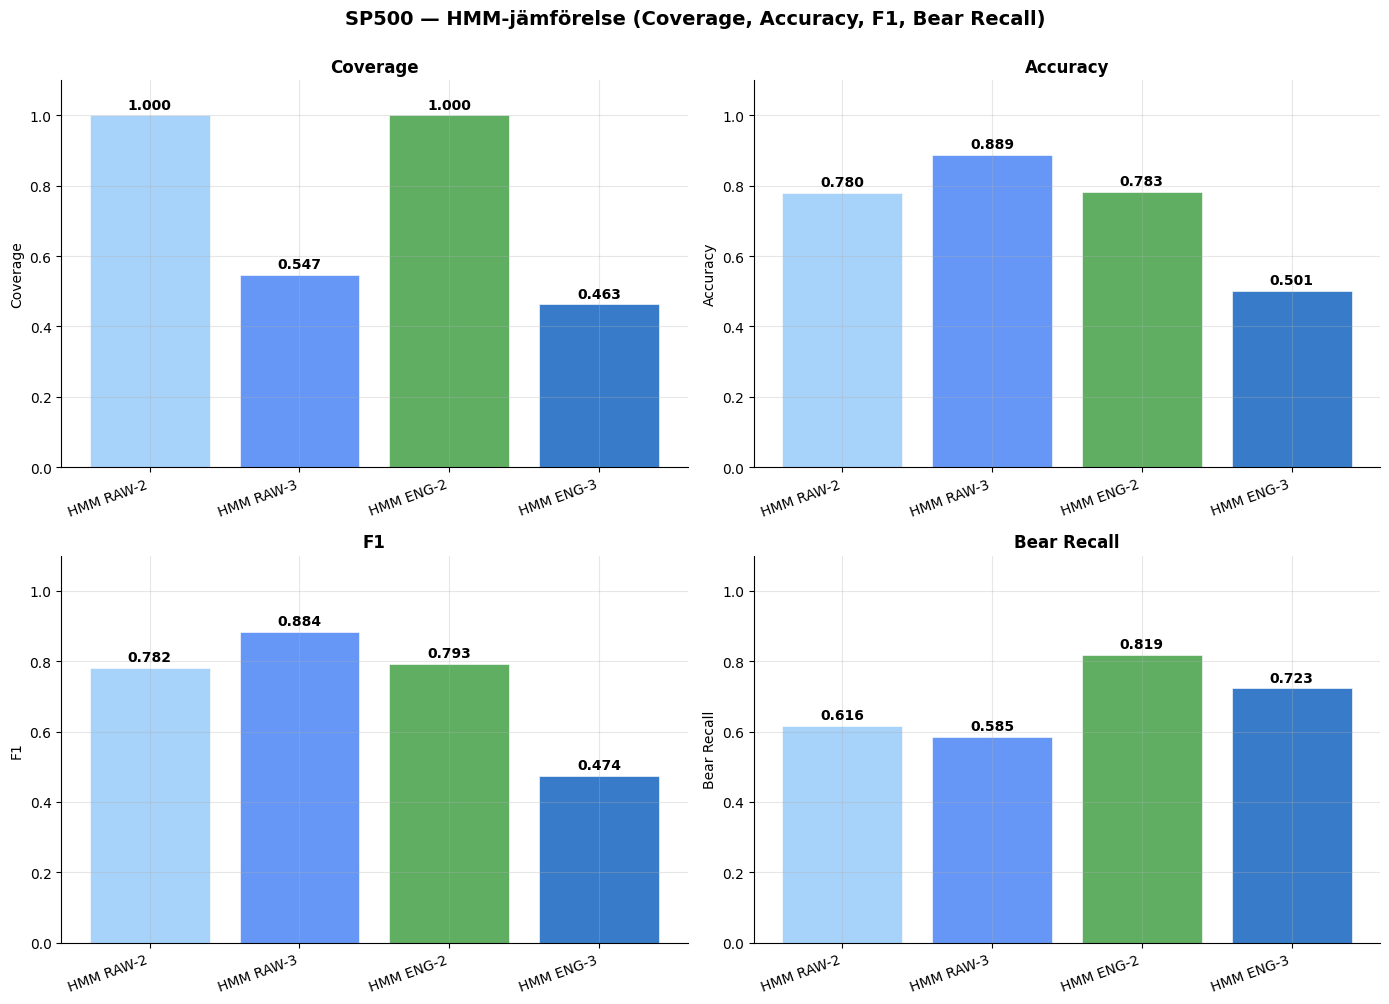

✓ Sparad: results/05_hmm_metrics.png


In [4]:
models = list(hmm_results.keys())
metrics = {
    'Coverage':    [hmm_results[m][0] for m in models],
    'Accuracy':    [hmm_results[m][1] for m in models],
    'F1':          [hmm_results[m][2] for m in models],
    'Bear Recall': [hmm_results[m][3] for m in models],
}
colors = ['#98CAF9', '#4B85F6', '#43A047', '#1565C0']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (metric, values) in zip(axes.flat, metrics.items()):
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('SP500 — HMM-jämförelse (Coverage, Accuracy, F1, Bear Recall)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '05_hmm_metrics.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Sparad: results/05_hmm_metrics.png')

### Vad ser vi?

- **2-state-modeller (RAW-2, ENG-2)** har 100% coverage — de klassificerar varje dag som Bull eller Bear (ingen Neutral i 2-state-modeller).
- **3-state-modeller (RAW-3, ENG-3)** har lägre coverage (47–55%) eftersom mellantillståndet (Neutral) exkluderas från utvärderingen.
- **ENG-2 dominerar Bear Recall** (0.819) — överlägset bäst på att fånga björndagar.
- **RAW-3 har högst Accuracy och F1** men endast på 55% av dagarna — den "lyckas" på lätta dagar men missar svåra övergångar.

## 6. Heatmap — alla mätetal samlat

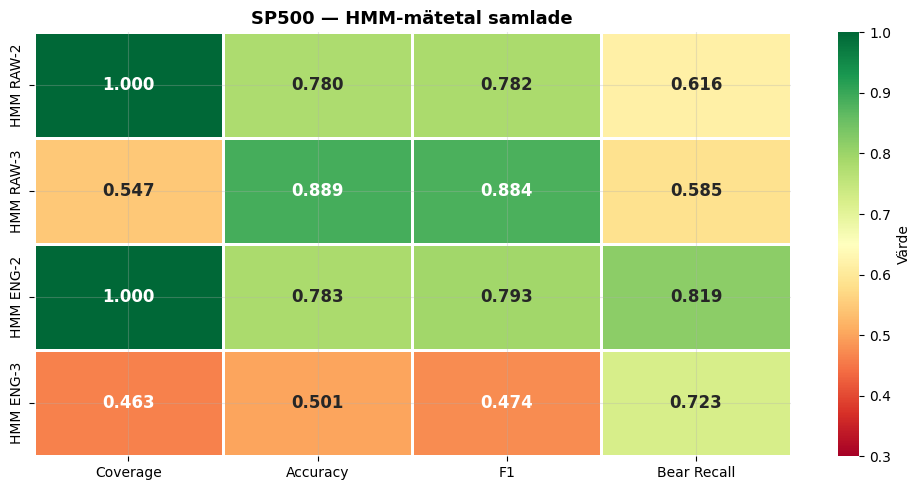

✓ Sparad: results/05_hmm_heatmap.png


In [5]:
heat_df = pd.DataFrame({
    'Coverage':    [hmm_results[m][0] for m in models],
    'Accuracy':    [hmm_results[m][1] for m in models],
    'F1':          [hmm_results[m][2] for m in models],
    'Bear Recall': [hmm_results[m][3] for m in models],
}, index=models)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat_df, ax=ax, annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0.3, vmax=1.0,
            linewidths=1, square=False,
            annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': 'Värde'})
ax.set_title('SP500 — HMM-mätetal samlade', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '05_hmm_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Sparad: results/05_hmm_heatmap.png')

## 7. Informationskriterier — log L, AIC, BIC

Acc/F1 förutsätter att HMM:s tillstånd matchar våra externa LT-etiketter. För **objektiv osupervised modelljämförelse** använder vi log-likelihood, AIC och BIC.

In [6]:
ic_df = pd.DataFrame([
    {'Modell': m, 'k (params)': v['k'], 'log L': v['log_L'],
     'AIC': v['AIC'], 'BIC': v['BIC']}
    for m, v in ic_results.items()
])

display(ic_df)

best_aic = ic_df.loc[ic_df['AIC'].idxmin(), 'Modell']
best_bic = ic_df.loc[ic_df['BIC'].idxmin(), 'Modell']
print(f'\n✓ Bästa modell enligt AIC: {best_aic}')
print(f'✓ Bästa modell enligt BIC: {best_bic}')

,Modell,k (params),log L,AIC,BIC
0,HMM RAW-2,7,-7849.2,15712.3,15759.8
1,HMM RAW-3,14,-7556.8,15141.6,15236.4
2,HMM ENG-2,13,-13228.5,26482.9,26571.0
3,HMM ENG-3,23,-10824.2,21694.4,21850.3



✓ Bästa modell enligt AIC: HMM RAW-3
✓ Bästa modell enligt BIC: HMM RAW-3


### Tolkning

- **RAW-3 vinner på både AIC och BIC** trots fler parametrar än RAW-2 — den extra komplexiteten är statistiskt motiverad.
- **ENG-modellerna har dramatiskt sämre fit** (log L ~−13000 mot RAW:s ~−7800) — extra features hjälper inte HMM, de förvirrar den.
- **Spänning mot F1-rangordningen:** RAW-3 vinner statistiskt (AIC/BIC) men ENG-2 vinner mot ground truth (F1 × Coverage). Det är klassisk osupervised-vs-supervised-divergens.

## 8. Bästa modell — två perspektiv

In [7]:
# F1 × Coverage (supervised perspektiv)
score_df = pd.DataFrame([
    {'Modell': m, 'Coverage': v[0], 'F1': v[2], 'F1 × Coverage': v[0] * v[2]}
    for m, v in hmm_results.items()
])
score_df = score_df.sort_values('F1 × Coverage', ascending=False)

print('═' * 70)
print('  Supervised perspektiv: F1 × Coverage')
print('═' * 70)
display(score_df)
best_supervised = score_df.iloc[0]['Modell']
print(f'\n✓ Bästa modell (F1 × Coverage): {best_supervised}')

print()
print('═' * 70)
print('  Osupervised perspektiv: AIC / BIC')
print('═' * 70)
print(f'  Bästa modell enligt AIC: {best_aic}')
print(f'  Bästa modell enligt BIC: {best_bic}')

══════════════════════════════════════════════════════════════════════
  Supervised perspektiv: F1 × Coverage
══════════════════════════════════════════════════════════════════════


,Modell,Coverage,F1,F1 × Coverage
2,HMM ENG-2,1.000,0.793,0.793000
0,HMM RAW-2,1.000,0.782,0.782000
1,HMM RAW-3,0.547,0.884,0.483548
3,HMM ENG-3,0.463,0.474,0.219462



✓ Bästa modell (F1 × Coverage): HMM ENG-2

══════════════════════════════════════════════════════════════════════
  Osupervised perspektiv: AIC / BIC
══════════════════════════════════════════════════════════════════════
  Bästa modell enligt AIC: HMM RAW-3
  Bästa modell enligt BIC: HMM RAW-3


### Vilken är "den bästa"?

Det beror på vad man värderar:

| Perspektiv | Vinnare | Motivering |
|---|---|---|
| **Praktisk (matcha LT-etiketter)** | ENG-2 | F1 × Coverage = 0.793; högst Bear Recall (0.819) |
| **Statistisk (förklara observerad data)** | RAW-3 | Lägst AIC och BIC — mest parsimonious modell som passar data bäst |

I en finansiell tillämpning är **ENG-2** att föredra — den fångar bearmarknader bäst med 100% coverage. **RAW-3** är teoretiskt mer välmotiverad men har låg coverage (54.7%), vilket gör den mindre praktiskt användbar.

## 9. Slutsatser — svar på forskningsfrågorna

In [8]:
print('═' * 70)
print('  SLUTSATSER')
print('═' * 70)

print('''
Huvudfråga:
Hur väl kan Hidden Markov Models identifiera bull- och bear-marknader
i S&P 500?

SVAR:
HMM identifierar bull/bear-regimer i SP500 med god prestanda. ENG-2
(volatilitet + volym, 2 tillstånd) presterar bäst med Accuracy 0.783,
F1 0.793 och Bear Recall 0.819 på 100% av dagarna. Modellen ser inte
ground truth-etiketterna under träning men hittar ändå ekonomiskt
meningsfulla regimer.

──────────────────────────────────────────────────────────────────────

RQ1: Hur påverkar antalet tillstånd (2 vs 3) HMM:s prestation?

SVAR:
- 2-state ger 100% coverage men något lägre F1 på "lätta" dagar
- 3-state ger högre F1 på de dagar som klassificeras (47–55% coverage)
  men exkluderar mellantillståndet från utvärderingen
- Praktiskt: 2-state är att föredra för full täckning
- Statistiskt: AIC/BIC favoriserar RAW-3 (lägst informationskriterier)

──────────────────────────────────────────────────────────────────────

RQ2: Hjälper engineered features (volatilitet, volym) HMM?

SVAR:
- ENG-2 vinner på Bear Recall (0.819) — tekniska indikatorer hjälper
  modellen identifiera bear-regimer
- ENG-modellerna har dock dramatiskt sämre log-likelihood än RAW
  (faktor ~1.7) — fler features ger inte automatiskt bättre fit
- För regimdetektering specifikt: ENG-2 är den starkaste modellen mot
  ground truth, RAW-3 är den starkaste modellen statistiskt
''')

══════════════════════════════════════════════════════════════════════
  SLUTSATSER
══════════════════════════════════════════════════════════════════════

Huvudfråga:
Hur väl kan Hidden Markov Models identifiera bull- och bear-marknader
i S&P 500?

SVAR:
HMM identifierar bull/bear-regimer i SP500 med god prestanda. ENG-2
(volatilitet + volym, 2 tillstånd) presterar bäst med Accuracy 0.783,
F1 0.793 och Bear Recall 0.819 på 100% av dagarna. Modellen ser inte
ground truth-etiketterna under träning men hittar ändå ekonomiskt
meningsfulla regimer.

──────────────────────────────────────────────────────────────────────

RQ1: Hur påverkar antalet tillstånd (2 vs 3) HMM:s prestation?

SVAR:
- 2-state ger 100% coverage men något lägre F1 på "lätta" dagar
- 3-state ger högre F1 på de dagar som klassificeras (47–55% coverage)
  men exkluderar mellantillståndet från utvärderingen
- Praktiskt: 2-state är att föredra för full täckning
- Statistiskt: AIC/BIC favoriserar RAW-3 (lägst informationskri

## 10. Sammanfattningstabell — examensarbetets huvudresultat

In [9]:
summary_data = []
for model, (cov, acc, f1, br) in hmm_results.items():
    summary_data.append({
        'Modell':       model,
        'Coverage':     f'{cov*100:.1f}%',
        'Accuracy':     f'{acc:.3f}',
        'F1':           f'{f1:.3f}',
        'Bear Recall':  f'{br:.3f}',
        'AIC':          f'{ic_results[model]["AIC"]:.1f}',
        'BIC':          f'{ic_results[model]["BIC"]:.1f}',
    })

df_summary = pd.DataFrame(summary_data)
display(df_summary)

df_summary.to_csv(os.path.join(RESULTS_DIR, '05_summary_table.csv'), index=False)
print('\n✓ Sammanfattningstabell sparad: results/05_summary_table.csv')

,Modell,Coverage,Accuracy,F1,Bear Recall,AIC,BIC
0,HMM RAW-2,100.0%,0.780,0.782,0.616,15712.3,15759.8
1,HMM RAW-3,54.7%,0.889,0.884,0.585,15141.6,15236.4
2,HMM ENG-2,100.0%,0.783,0.793,0.819,26482.9,26571.0
3,HMM ENG-3,46.3%,0.501,0.474,0.723,21694.4,21850.3



✓ Sammanfattningstabell sparad: results/05_summary_table.csv
